In [19]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [18]:
class batsmanState(TypedDict):
    runs : int
    balls : int
    fours : int 
    sixes : int

    strike_rate : float
    bpb : float
    boundary_percentage : float
    summarize : str

In [17]:
def calculate_sr(state : batsmanState):
    runs = state["runs"]
    balls = state["balls"]

    sr = (runs/balls)*100

    return {"strike_rate":sr}

In [16]:
def calcualte_boundary_percentage(state : batsmanState):
    runs = state["runs"]
    fours = state["fours"]
    sixes = state["sixes"]

    bp = ((fours*4 + sixes*6)/runs)*100

    return {"boundary_percentage":bp}

In [15]:
def calculate_bpb(state : batsmanState):
    balls = state["balls"]
    fours = state["fours"]
    sixes = state["sixes"]

    bpb = balls/(fours + sixes)

    return {"bpb":bpb}

In [36]:
def summarize(state : batsmanState):
    performance = f"""Batsman Performance is \n 
    Runs - {state["runs"]}  
    Balls - {state["balls"]}  
    Fours - {state["fours"]} 
    Sixes - {state["sixes"]} 
    Strike_Rate - {state["strike_rate"]} 
    Ball Per Boundary - {state["bpb"]} 
    Boundary Percentage - {state["boundary_percentage"]}
"""
    
    return {"summarize" : performance}

In [37]:
graph = StateGraph(batsmanState)

graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calcualte_boundary_percentage",calcualte_boundary_percentage)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("summarize",summarize)

graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calcualte_boundary_percentage")

graph.add_edge("calculate_sr","summarize")
graph.add_edge("calculate_bpb","summarize")
graph.add_edge("calcualte_boundary_percentage","summarize")
graph.add_edge("summarize",END)

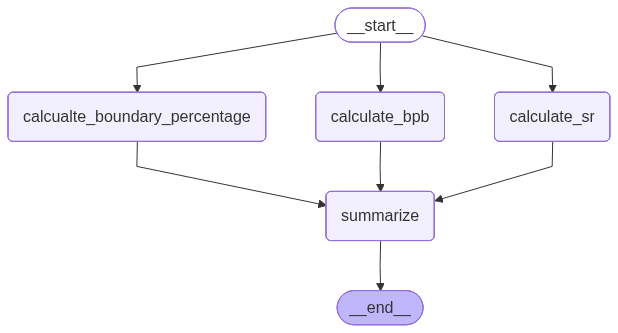

In [38]:
workflow = graph.compile()
graph.compile()

In [39]:
initial_state = {"runs":100,"balls":50,"fours":5,"sixes":7}
final_state = workflow.invoke(initial_state)

In [40]:
print(final_state["summarize"])

Batsman Performance is 
 
    Runs - 100  
    Balls - 50  
    Fours - 5 
    Sixes - 7 
    Strike_Rate - 200.0 
    Ball Per Boundary - 4.166666666666667 
    Boundary Percentage - 62.0

